# Fake Job Posting Detection Using NLP
# Mini NLP Project
# TF-IDF + Logistic Regression

# Fake Job Posting Detection Using NLP

## Mini NLP Project

This project develops an NLP-based machine learning system to detect
whether an online job posting is legitimate or fraudulent.

The project uses the Real / Fake Job Posting Prediction dataset obtained
from Kaggle.

Natural Language Processing is used to process the textual content of
job advertisements.

TF-IDF is used to convert text into numerical features, and Logistic
Regression is used to classify job postings.

Final outputs:

- REAL
- FAKE

The system also provides a confidence score along with the prediction.

## 1. Problem Statement

Online recruitment platforms contain a large number of job advertisements.
Among these advertisements, some may be fraudulent and can mislead
job seekers.

Manually checking every job advertisement is difficult when the number
of postings is large.

Therefore, this project aims to develop an automated Natural Language
Processing system that analyzes the text of a job posting and predicts
whether the posting is:

1. REAL / Legitimate
2. FAKE / Fraudulent

The system also provides a confidence score for each prediction.

## 2. Objectives

The main objectives of this project are:

1. To obtain a real-world fake job posting dataset from Kaggle.
2. To explore and understand the dataset.
3. To identify missing values and class imbalance.
4. To preprocess job advertisement text.
5. To combine important textual fields into a single text representation.
6. To convert text into numerical features using TF-IDF.
7. To train a Logistic Regression classification model.
8. To classify job postings as REAL or FAKE.
9. To calculate the confidence of each prediction.
10. To evaluate the model using accuracy, precision, recall and F1-score.
11. To visualize classification performance using a confusion matrix.
12. To test the trained model using new job postings.

## 3. Dataset

The dataset used in this project is the Real / Fake Job Posting
Prediction dataset available on Kaggle.

The dataset is based on the Employment Scam Aegean Dataset (EMSCAD).

It contains job advertisements along with information such as:

- Job title
- Location
- Department
- Salary range
- Company profile
- Job description
- Requirements
- Benefits
- Employment type
- Required experience
- Required education
- Industry
- Job function

The target variable is "fraudulent".

Target values:

0 → REAL / Legitimate
1 → FAKE / Fraudulent

In [6]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
# Upload Kaggle dataset

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving fake_job_postings.csv to fake_job_postings (1).csv
Dataset uploaded successfully!


## 5. Load Dataset

The uploaded CSV file is loaded into a Pandas DataFrame.

Pandas is used to inspect, clean and process the dataset.

In [8]:
# Identify the uploaded file

file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df.shape)

Dataset loaded successfully!
File name: fake_job_postings (1).csv
Dataset shape: (17880, 18)


## 6. Display the Dataset

The first five records are displayed to understand the structure
and content of the job postings.

In [9]:
# Display first five rows

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 7. Dataset Information

The dataset information is examined to identify:

- Column names
- Number of records
- Data types
- Non-null values

This helps us understand the structure of the dataset before
performing preprocessing.

In [10]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

## 8. Dataset Columns

The dataset contains both textual and non-textual attributes.

Important textual attributes for this NLP project include:

- title
- company_profile
- description
- requirements
- benefits

The target variable is:

- fraudulent

The fraudulent column is used to determine whether a job posting
is REAL or FAKE.

In [11]:
# Display all column names

print("Dataset Columns:\n")

for number, column in enumerate(df.columns, start=1):
    print(number, ".", column)

Dataset Columns:

1 . job_id
2 . title
3 . location
4 . department
5 . salary_range
6 . company_profile
7 . description
8 . requirements
9 . benefits
10 . telecommuting
11 . has_company_logo
12 . has_questions
13 . employment_type
14 . required_experience
15 . required_education
16 . industry
17 . function
18 . fraudulent


## 9. Missing Value Analysis

Some job advertisements may not contain information in every field.

Missing values are checked before preprocessing.

This step is important because missing textual values must be handled
before combining multiple text fields.

In [12]:
# Calculate missing values

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
})

missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

missing_table

,Missing Values,Percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


## 10. Target Variable Analysis

The target variable is "fraudulent".

The target values represent:

0 → REAL / Legitimate
1 → FAKE / Fraudulent

The number of records in each class is calculated to understand
the distribution of REAL and FAKE job postings.

In [13]:
# Count REAL and FAKE job postings

class_counts = df["fraudulent"].value_counts().sort_index()

print("Class Distribution:\n")

print(
    "REAL / Legitimate:",
    class_counts.get(0, 0)
)

print(
    "FAKE / Fraudulent:",
    class_counts.get(1, 0)
)

Class Distribution:

REAL / Legitimate: 17014
FAKE / Fraudulent: 866


## 11. Class Distribution Visualization

A bar chart is created to visualize the number of REAL and FAKE
job postings.

This visualization helps identify class imbalance in the dataset.

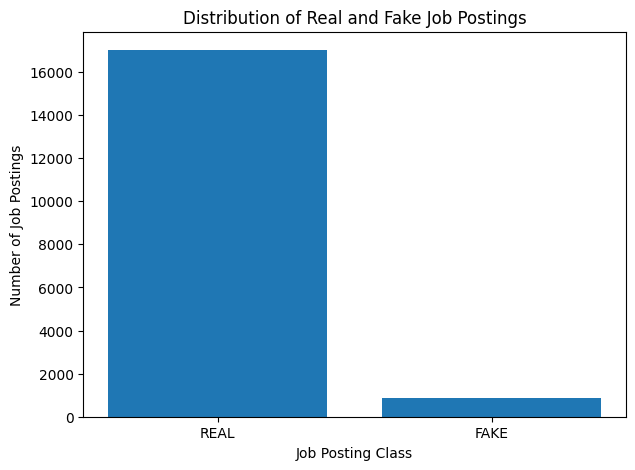

In [14]:
# Visualize class distribution

plt.figure(figsize=(7, 5))

plt.bar(
    ["REAL", "FAKE"],
    [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
)

plt.title("Distribution of Real and Fake Job Postings")
plt.xlabel("Job Posting Class")
plt.ylabel("Number of Job Postings")

plt.show()

## 12. Class Imbalance

The dataset contains considerably more REAL job postings than
FAKE job postings.

This is known as class imbalance.

Class imbalance can cause a machine learning model to favor the
majority class.

To reduce this problem, class_weight="balanced" is used in the
Logistic Regression model.

The model is also evaluated using precision, recall and F1-score
instead of relying only on accuracy.

## 13. Selecting Text Features

The following textual fields are selected for Natural Language
Processing:

1. title
2. company_profile
3. description
4. requirements
5. benefits

These fields contain information about the job, company, duties,
requirements and benefits.

The selected fields will be combined into a single text field.

In [15]:
# Select important text columns

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Replace missing values with empty strings

for column in text_columns:
    df[column] = df[column].fillna("")

print("Text fields prepared successfully!")

Text fields prepared successfully!


## 14. Combining Text Fields

Multiple textual fields are combined into one column called
"combined_text".

This provides the NLP model with more information about each
job advertisement.

The combined text contains:

Title
+
Company Profile
+
Description
+
Requirements
+
Benefits

In [16]:
# Combine selected text fields

df["combined_text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

print("Text fields combined successfully!")

df["combined_text"].head()

Text fields combined successfully!


,combined_text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


## 15. Text Preprocessing

Raw job-posting text can contain unnecessary elements such as
HTML tags, URLs, special characters and extra spaces.

The following preprocessing steps are applied:

1. Convert text to lowercase.
2. Remove HTML tags.
3. Remove URLs.
4. Remove special characters.
5. Remove extra spaces.

The cleaned text is then used for TF-IDF feature extraction.

In [17]:
# Define text preprocessing function

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


print("Text preprocessing function created successfully!")

Text preprocessing function created successfully!


## 16. Apply Text Preprocessing

The preprocessing function is applied to the combined job-posting
text.

A new column called "clean_text" is created.

This cleaned text becomes the input for the NLP model.

In [18]:
# Apply text preprocessing

df["clean_text"] = df["combined_text"].apply(clean_text)

# Display original and cleaned text

df[["combined_text", "clean_text"]].head()

,combined_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


## 17. Remove Empty Text Records

After preprocessing, some records may contain no meaningful text.

Such records are removed so that the machine learning model receives
valid textual information.

In [19]:
# Remove records with empty text

before_count = len(df)

df = df[
    df["clean_text"].str.strip() != ""
].copy()

after_count = len(df)

print("Records before:", before_count)
print("Records after :", after_count)
print("Records removed:", before_count - after_count)

Records before: 17880
Records after : 17880
Records removed: 0


## 18. Define Input and Target

The cleaned job-posting text is used as the input variable X.

The "fraudulent" column is used as the target variable y.

Input X:
Cleaned job-posting text

Target y:
0 → REAL
1 → FAKE

In [20]:
# Define input and target

X = df["clean_text"]
y = df["fraudulent"]

print("Input samples :", len(X))
print("Target samples:", len(y))

Input samples : 17880
Target samples: 17880


## 19. Train-Test Split

The dataset is divided into two parts:

80% → Training Data
20% → Testing Data

Training data is used to learn patterns from the job postings.

Testing data is used to evaluate the model on previously unseen
job postings.

Stratified splitting is used to maintain the proportion of REAL
and FAKE postings in both datasets.

In [21]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 14304
Testing samples : 3576


## 20. TF-IDF Feature Extraction

Machine learning algorithms cannot directly understand raw text.

Therefore, TF-IDF is used to convert the job-posting text into
numerical feature vectors.

TF-IDF represents the importance of words within documents.

This project uses:

- Unigrams: individual words
- Bigrams: two-word combinations

Example:

Unigram:
"salary"

Bigram:
"high salary"

Using unigrams and bigrams allows the model to learn both individual
words and short phrases.

In [22]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit TF-IDF only on training data

X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the learned vocabulary

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

TF-IDF transformation completed!
Training TF-IDF shape: (14304, 100000)
Testing TF-IDF shape: (3576, 100000)


## 21. Why TF-IDF is Fitted Only on Training Data

The TF-IDF vectorizer is fitted only on the training data.

The test data is transformed using the vocabulary learned from the
training data.

This prevents information from the test dataset from influencing
the training process and helps avoid data leakage.

## 22. Logistic Regression

Logistic Regression is selected as the machine learning algorithm.

This project is a binary classification problem:

0 → REAL
1 → FAKE

Logistic Regression is suitable for text classification because it
works effectively with high-dimensional sparse features such as
TF-IDF vectors.

The balanced class-weight option is used because the dataset is
imbalanced.

In [23]:
# Create Logistic Regression model

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model

model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 23. Generate Predictions

The trained Logistic Regression model is used to classify the
unseen test job postings.

The model produces a binary prediction:

0 → REAL
1 → FAKE

In [24]:
# Generate predictions

y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 24. Model Evaluation

The performance of the model is evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1-score

Accuracy:
Measures the percentage of all predictions that are correct.

Precision:
Measures how many jobs predicted as FAKE are actually FAKE.

Recall:
Measures how many actual FAKE jobs are correctly detected.

F1-score:
Provides a balance between precision and recall.

In [25]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("========== MODEL PERFORMANCE ==========")

print(
    "Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall   :",
    round(recall, 4)
)

print(
    "F1 Score :",
    round(f1, 4)
)

========== MODEL PERFORMANCE ==========
Accuracy : 98.83 %
Precision: 0.8579
Recall   : 0.9075
F1 Score : 0.882


## 25. Classification Report

A detailed classification report is generated for both REAL and
FAKE classes.

The report contains:

- Precision
- Recall
- F1-score
- Support

Support represents the number of actual samples belonging to each
class in the test dataset.

In [26]:
# Display classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=["REAL", "FAKE"],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

        REAL       1.00      0.99      0.99      3403
        FAKE       0.86      0.91      0.88       173

    accuracy                           0.99      3576
   macro avg       0.93      0.95      0.94      3576
weighted avg       0.99      0.99      0.99      3576



## 26. Confusion Matrix

A confusion matrix is used to understand the correct and incorrect
predictions made by the model.

The four outcomes are:

True Positive:
A FAKE job correctly classified as FAKE.

True Negative:
A REAL job correctly classified as REAL.

False Positive:
A REAL job incorrectly classified as FAKE.

False Negative:
A FAKE job incorrectly classified as REAL.

False negatives are important in this project because a fraudulent
job incorrectly classified as REAL may potentially mislead a job seeker.

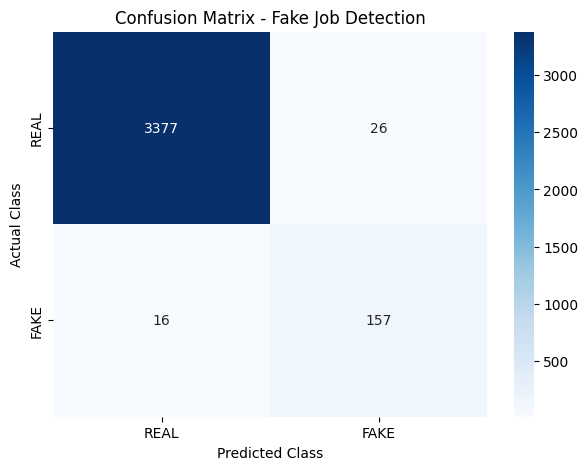

In [27]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.title("Confusion Matrix - Fake Job Detection")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.title("Confusion Matrix - Fake Job Detection")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [28]:
# Generate class probabilities

probabilities = model.predict_proba(
    X_test_tfidf
)

# Probability of REAL class
real_probability = probabilities[:, 0]

# Probability of FAKE class
fake_probability = probabilities[:, 1]

# Select the higher probability
confidence = np.maximum(
    real_probability,
    fake_probability
)

# Convert probability to class label
prediction_labels = np.where(
    fake_probability >= real_probability,
    "FAKE",
    "REAL"
)

# Create results table
prediction_results = pd.DataFrame({
    "Actual": np.where(
        y_test.values == 1,
        "FAKE",
        "REAL"
    ),
    "Predicted": prediction_labels,
    "Real Probability (%)": (
        real_probability * 100
    ).round(2),
    "Fake Probability (%)": (
        fake_probability * 100
    ).round(2),
    "Confidence (%)": (
        confidence * 100
    ).round(2)
})

prediction_results.head(10)

,Actual,Predicted,Real Probability (%),Fake Probability (%),Confidence (%)
0,REAL,REAL,69.93,30.07,69.93
1,REAL,REAL,94.19,5.81,94.19
2,REAL,REAL,94.41,5.59,94.41
3,REAL,REAL,97.51,2.49,97.51
4,REAL,REAL,95.75,4.25,95.75
5,REAL,REAL,96.50,3.50,96.50
6,REAL,REAL,93.23,6.77,93.23
7,REAL,REAL,92.41,7.59,92.41
8,REAL,REAL,94.10,5.90,94.10
9,REAL,REAL,89.47,10.53,89.47


## 28. Prediction Confidence Distribution

The confidence score represents the probability of the class selected
by the model.

A confidence close to 100% indicates a stronger model prediction,
while a confidence closer to 50% indicates that the model is less
certain between REAL and FAKE.

The prediction itself remains binary.

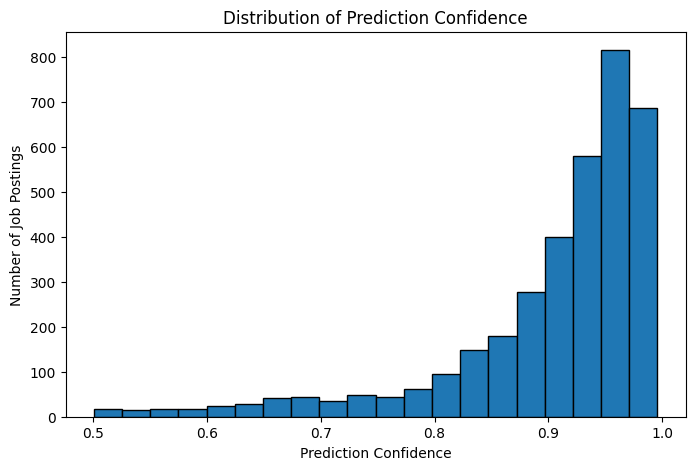

In [29]:
# Plot confidence distribution

plt.figure(figsize=(8, 5))

plt.hist(
    confidence,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Prediction Confidence")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Job Postings")

plt.show()

## 29. Predicted Class Distribution

The number of job postings predicted as REAL and FAKE is calculated.

This provides an overview of how the trained model classifies the
unseen test job postings.

In [30]:
# Count predicted classes

prediction_counts = pd.Series(
    prediction_labels
).value_counts()

print("Predicted Class Distribution:")
print(prediction_counts)

Predicted Class Distribution:
REAL    3393
FAKE     183
Name: count, dtype: int64


## 30. Predicted Class Visualization

A bar chart is created to visualize the number of job postings
predicted as REAL and FAKE by the trained model.

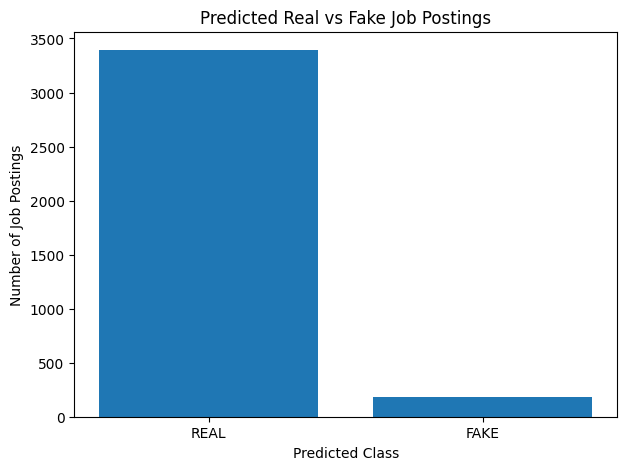

In [31]:
# Plot predicted class distribution

plt.figure(figsize=(7, 5))

plt.bar(
    ["REAL", "FAKE"],
    [
        prediction_counts.get("REAL", 0),
        prediction_counts.get("FAKE", 0)
    ]
)

plt.title("Predicted Real vs Fake Job Postings")
plt.xlabel("Predicted Class")
plt.ylabel("Number of Job Postings")

plt.show()

## 31. Testing the Model with a New Job Posting

The trained model is tested using a new job advertisement.

The new job posting goes through the same processing steps used
during training:

1. Text preprocessing
2. TF-IDF transformation
3. Logistic Regression prediction
4. Probability calculation
5. Final REAL or FAKE classification

The system also displays the confidence of the prediction.

In [32]:
# New job posting

sample_job = """
URGENT HIRING!

Work from home and earn $5000 every week.
No previous experience required.
Immediate joining available.
Send your personal information and pay a registration fee
to secure your employment.
"""

# Clean the text
sample_clean = clean_text(sample_job)

# Convert text into TF-IDF features
sample_vector = tfidf.transform(
    [sample_clean]
)

# Get probabilities
sample_probabilities = model.predict_proba(
    sample_vector
)[0]

sample_real_probability = sample_probabilities[0]
sample_fake_probability = sample_probabilities[1]

# Determine prediction
if sample_fake_probability >= sample_real_probability:
    sample_prediction = "FAKE"
    sample_confidence = sample_fake_probability
else:
    sample_prediction = "REAL"
    sample_confidence = sample_real_probability

# Display result
print("========== JOB ANALYSIS ==========")

print(
    "Real Probability:",
    round(sample_real_probability * 100, 2),
    "%"
)

print(
    "Fake Probability:",
    round(sample_fake_probability * 100, 2),
    "%"
)

print(
    "Prediction:",
    sample_prediction
)

print(
    "Confidence:",
    round(sample_confidence * 100, 2),
    "%"
)

========== JOB ANALYSIS ==========
Real Probability: 14.74 %
Fake Probability: 85.26 %
Prediction: FAKE
Confidence: 85.26 %


## 32. Testing Another Job Posting

A second job advertisement is tested to demonstrate how the model
handles a different type of job description.

The output contains:

- REAL probability
- FAKE probability
- Final prediction
- Confidence

In [33]:
# Another job posting

sample_job_2 = """
We are looking for a Software Engineer to join our development team.
The candidate should have experience with Python, SQL and software
development. The selected candidate will work with our engineering
team to develop and maintain software applications.
"""

# Clean text
sample_clean_2 = clean_text(
    sample_job_2
)

# Convert to TF-IDF
sample_vector_2 = tfidf.transform(
    [sample_clean_2]
)

# Get probabilities
sample_probabilities_2 = model.predict_proba(
    sample_vector_2
)[0]

sample_real_probability_2 = sample_probabilities_2[0]
sample_fake_probability_2 = sample_probabilities_2[1]

# Determine prediction
if sample_fake_probability_2 >= sample_real_probability_2:
    sample_prediction_2 = "FAKE"
    sample_confidence_2 = sample_fake_probability_2
else:
    sample_prediction_2 = "REAL"
    sample_confidence_2 = sample_real_probability_2

# Display result
print("========== JOB ANALYSIS ==========")

print(
    "Real Probability:",
    round(sample_real_probability_2 * 100, 2),
    "%"
)

print(
    "Fake Probability:",
    round(sample_fake_probability_2 * 100, 2),
    "%"
)

print(
    "Prediction:",
    sample_prediction_2
)

print(
    "Confidence:",
    round(sample_confidence_2 * 100, 2),
    "%"
)

========== JOB ANALYSIS ==========
Real Probability: 90.66 %
Fake Probability: 9.34 %
Prediction: REAL
Confidence: 90.66 %


## 33. Testing Multiple Job Postings

Multiple job advertisements are tested to demonstrate the practical
operation of the trained system.

For every job posting, the system displays:

- Real probability
- Fake probability
- Prediction
- Confidence

The final output is always either REAL or FAKE.

In [34]:
# Multiple sample job postings

sample_jobs = [

    """
    Software Engineer required with experience in Python,
    SQL and machine learning. Full-time position with
    competitive salary and benefits.
    """,

    """
    Earn $10,000 every week from home.
    No experience required.
    Pay a small registration fee today to guarantee your job.
    """,

    """
    Marketing Manager required with three years of experience.
    Responsibilities include campaign planning, market analysis
    and coordination with the marketing team.
    """
]

print("========== MULTIPLE JOB ANALYSIS ==========\n")

for number, job in enumerate(
    sample_jobs,
    start=1
):

    # Clean text
    cleaned_job = clean_text(job)

    # TF-IDF transformation
    job_vector = tfidf.transform(
        [cleaned_job]
    )

    # Get probabilities
    job_probabilities = model.predict_proba(
        job_vector
    )[0]

    real_prob = job_probabilities[0]
    fake_prob = job_probabilities[1]

    # Final prediction
    if fake_prob >= real_prob:
        prediction = "FAKE"
        prediction_confidence = fake_prob
    else:
        prediction = "REAL"
        prediction_confidence = real_prob

    print("Job", number)

    print(
        "Real Probability:",
        round(real_prob * 100, 2),
        "%"
    )

    print(
        "Fake Probability:",
        round(fake_prob * 100, 2),
        "%"
    )

    print(
        "Prediction:",
        prediction
    )

    print(
        "Confidence:",
        round(prediction_confidence * 100, 2),
        "%"
    )

    print("-" * 45)

========== MULTIPLE JOB ANALYSIS ==========

Job 1
Real Probability: 77.18 %
Fake Probability: 22.82 %
Prediction: REAL
Confidence: 77.18 %
---------------------------------------------
Job 2
Real Probability: 21.11 %
Fake Probability: 78.89 %
Prediction: FAKE
Confidence: 78.89 %
---------------------------------------------
Job 3
Real Probability: 74.17 %
Fake Probability: 25.83 %
Prediction: REAL
Confidence: 74.17 %
---------------------------------------------


## 34. Final Model Performance Summary

The main performance metrics obtained from the test dataset are
displayed in a single table.

The metrics are:

- Accuracy
- Precision
- Recall
- F1-score

The values displayed here are the actual results obtained from
the trained model.

In [35]:
# Create final performance table

performance_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

performance_df

,Metric,Score
0,Accuracy,0.988255
1,Precision,0.857923
2,Recall,0.907514
3,F1 Score,0.882022


## 35. Model Performance Visualization

A bar chart is created to compare the performance metrics of the
fake job detection model.

This visualization can be included in the project report and
PowerPoint presentation.

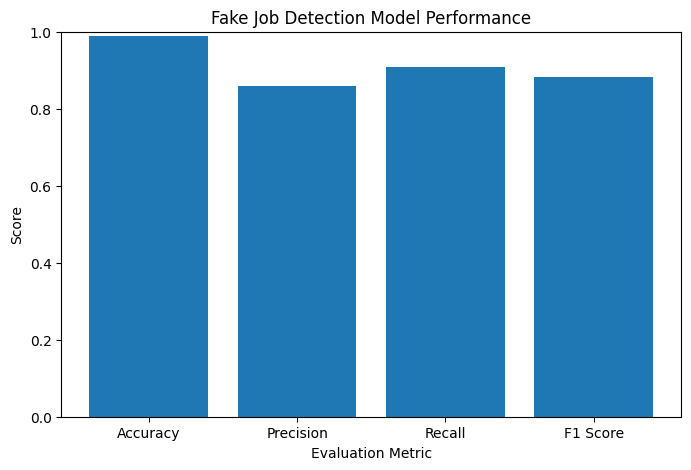

In [36]:
# Plot performance metrics

plt.figure(figsize=(8, 5))

plt.bar(
    performance_df["Metric"],
    performance_df["Score"]
)

plt.ylim(0, 1)

plt.title("Fake Job Detection Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.show()

## 36. Save the Trained Model

The trained Logistic Regression model and TF-IDF vectorizer are
saved using Joblib.

Saving these files allows the trained model to be reused later
without training it again.

In [37]:
# Save the trained model

joblib.dump(
    model,
    "fake_job_model.pkl"
)

# Save the TF-IDF vectorizer

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Model saved successfully!")
print("Vectorizer saved successfully!")

Model saved successfully!
Vectorizer saved successfully!


## 37. Download Trained Model Files

The trained model and TF-IDF vectorizer can be downloaded from
Google Colab.

These files can later be used for deployment in a web application.

In [38]:
# Download trained model

files.download(
    "fake_job_model.pkl"
)

# Download TF-IDF vectorizer

files.download(
    "tfidf_vectorizer.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 38. Complete System Workflow

The complete fake job detection system follows the workflow below:

Kaggle Dataset
       ↓
Data Exploration
       ↓
Missing Value Analysis
       ↓
Text Feature Selection
       ↓
Text Combination
       ↓
Text Preprocessing
       ↓
Train-Test Split
       ↓
TF-IDF Feature Extraction
       ↓
Logistic Regression
       ↓
Probability Prediction
       ↓
REAL / FAKE Classification
       ↓
Confidence Calculation
       ↓
Model Evaluation
       ↓
Final Results

## 39. Limitations

The project has several limitations:

1. The dataset is highly imbalanced because fraudulent job postings
   are much fewer than legitimate job postings.

2. The dataset represents job advertisements from an earlier period,
   so modern fraudulent-job techniques may not be fully represented.

3. TF-IDF mainly captures word and phrase patterns and does not provide
   deep contextual understanding.

4. Some legitimate job postings may be incorrectly classified as fake.

5. Some sophisticated fraudulent job postings may be classified as real.

6. The system relies heavily on the patterns present in the training
   dataset.

7. The confidence score represents the model's prediction probability
   and should not be interpreted as proof that a job posting is actually
   fraudulent.

## 40. Future Scope

The system can be improved in several ways:

1. Use BERT or Transformer-based models for better contextual
   understanding.

2. Add multilingual fake job detection.

3. Include additional job-posting metadata along with text.

4. Develop an explainable AI system to show which words or features
   influenced the prediction.

5. Develop a web application where users can paste a job advertisement
   and receive a REAL or FAKE prediction.

6. Develop a browser extension for analyzing job advertisements
   while users browse recruitment websites.

7. Continuously retrain the model using newer fraudulent job postings.

8. Compare Logistic Regression with other algorithms such as SVM,
   Random Forest and Naive Bayes.

## 41. Conclusion

This project developed an NLP-based machine learning system for
detecting fraudulent job postings.

The textual information from job advertisements was combined and
preprocessed before being converted into numerical features using
TF-IDF.

A Logistic Regression classifier was trained to distinguish between
legitimate and fraudulent job postings.

The system performs binary classification and produces one of two
outputs:

REAL
or
FAKE

The system also provides a confidence score associated with the
prediction.

The model was evaluated using accuracy, precision, recall, F1-score
and a confusion matrix.

The project demonstrates how Natural Language Processing and machine
learning can be applied to a practical problem in online recruitment
and job-search safety.